<a href="https://colab.research.google.com/github/sxdattt/NorthStar-Urban-Mobility-Analytics/blob/main/notebooks/Python_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Data Cleaning, Consolidation & NumPy/Pandas Analysis

This notebook loads all 11 NorthStar CSVs, performs comprehensive data cleaning, consolidates them into a unified dataframe, applies NumPy and Pandas analysis, and produces pairplots for all numerical features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

print("✅ All libraries imported successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   seaborn : {sns.__version__}")

✅ All libraries imported successfully.
   pandas  : 2.2.2
   numpy   : 2.0.2
   seaborn : 0.13.2


### All CSVs are loaded directly from the public GitHub repository using raw URLs.

In [2]:
BASE = "https://raw.githubusercontent.com/sxdattt/NorthStar-Urban-Mobility-Analytics/main/"

files = {
    "orders"     : "orders.csv",
    "deliveries" : "deliveries.csv",
    "customers"  : "customers.csv",
    "complaints" : "complaints.csv",
    "drivers"    : "drivers.csv",
    "vehicles"   : "vehicles.csv",
    "hubs"       : "hubs.csv",
    "incidents"  : "incidents.csv",
    "app_events" : "app_events.csv",
    "data_dict"  : "data_dictionary.csv",
}

dfs = {}
for name, fname in files.items():
    try:
        dfs[name] = pd.read_csv(BASE + fname, na_values=["", "NA", "N/A", "null"])
        print(f"  ✅ {name:<15} {dfs[name].shape[0]:>5} rows × {dfs[name].shape[1]:>2} cols")
    except Exception as e:
        print(f"  ❌ {name}: {e}")

# Assign to named variables
orders     = dfs["orders"].copy()
deliveries = dfs["deliveries"].copy()
customers  = dfs["customers"].copy()
complaints = dfs["complaints"].copy()
drivers    = dfs["drivers"].copy()
vehicles   = dfs["vehicles"].copy()
hubs       = dfs["hubs"].copy()
incidents  = dfs["incidents"].copy()
app_events = dfs["app_events"].copy()
data_dict  = dfs["data_dict"].copy()

print("\n All datasets loaded.")

  ✅ orders           1250 rows × 11 cols
  ✅ deliveries        950 rows × 13 cols
  ✅ customers         650 rows ×  9 cols
  ✅ complaints        320 rows × 10 cols
  ✅ drivers           170 rows ×  8 cols
  ✅ vehicles          120 rows ×  8 cols
  ✅ hubs                8 rows ×  5 cols
  ✅ incidents         280 rows ×  7 cols
  ✅ app_events        640 rows × 10 cols
  ✅ data_dict           9 rows ×  3 cols

✅ All datasets loaded.


## Data Cleaning — Orders Dataset

In [3]:
print("── Orders: Before Cleaning ──")
print(f"Shape      : {orders.shape}")
print(f"Duplicates : {orders.duplicated().sum()}")
print("\nMissing values:")
print(orders.isnull().sum()[orders.isnull().sum() > 0])

# Parse dates
date_cols = [c for c in orders.columns if "date" in c.lower() or "at" in c.lower()]
for col in date_cols:
    try:
        orders[col] = pd.to_datetime(orders[col], errors="coerce")
    except:
        pass

# Coerce numeric columns
num_cols = ["order_value", "distance_km", "promised_window_hours"]
for col in num_cols:
    if col in orders.columns:
        orders[col] = pd.to_numeric(orders[col], errors="coerce")

# Remove duplicates
orders.drop_duplicates(inplace=True)

# Fill minor missing values
if "order_status" in orders.columns:
    orders["order_status"].fillna("unknown", inplace=True)

# Derived columns
if "order_created_at" in orders.columns:
    orders["order_date"]  = pd.to_datetime(orders["order_created_at"], errors="coerce")
    orders["order_month"] = orders["order_date"].dt.to_period("M").astype(str)
    orders["order_dow"]   = orders["order_date"].dt.day_name()

print("\n── Orders: After Cleaning ──")
print(f"Shape      : {orders.shape}")
print(f"Duplicates : {orders.duplicated().sum()}")
print(f"Date range : {orders['order_date'].min()} → {orders['order_date'].max()}")
print("\n✅ Orders cleaning complete.")

── Orders: Before Cleaning ──
Shape      : (1250, 11)
Duplicates : 0

Missing values:
booking_channel    25
dtype: int64

── Orders: After Cleaning ──
Shape      : (1250, 14)
Duplicates : 0
Date range : 2024-01-01 01:29:00 → 2025-12-31 14:49:00

✅ Orders cleaning complete.


## Data Cleaning — Deliveries, Customers & Complaints

In [4]:
# ── Deliveries ──
deliveries.drop_duplicates(inplace=True)
date_cols_d = [c for c in deliveries.columns if "date" in c.lower() or "at" in c.lower()]
for col in date_cols_d:
    deliveries[col] = pd.to_datetime(deliveries[col], errors="coerce")
for col in ["fuel_or_charge_cost", "route_distance_km", "customer_rating_post_delivery"]:
    if col in deliveries.columns:
        deliveries[col] = pd.to_numeric(deliveries[col], errors="coerce")
if "fuel_or_charge_cost" in deliveries.columns and "route_distance_km" in deliveries.columns:
    deliveries["cost_per_km"] = (
        deliveries["fuel_or_charge_cost"] / (deliveries["route_distance_km"] + 0.001)
    ).round(2)
print(f"deliveries cleaned : {deliveries.shape}")

# ── Customers ──
customers.drop_duplicates(inplace=True)
for col in ["loyalty_score", "total_orders", "total_spend"]:
    if col in customers.columns:
        customers[col] = pd.to_numeric(customers[col], errors="coerce")
print(f"customers  cleaned : {customers.shape}")

# ── Complaints ──
complaints.drop_duplicates(inplace=True)
complaints_clean = complaints.dropna(subset=["order_id"])
print(f"complaints cleaned : {complaints_clean.shape}")

# ── Drivers ──
drivers.drop_duplicates(inplace=True)
for col in ["driver_rating", "training_score", "years_experience"]:
    if col in drivers.columns:
        drivers[col] = pd.to_numeric(drivers[col], errors="coerce")
print(f"drivers    cleaned : {drivers.shape}")

# ── Vehicles ──
vehicles.drop_duplicates(inplace=True)
print(f"vehicles   cleaned : {vehicles.shape}")

print("\n✅ All tables cleaned.")

deliveries cleaned : (950, 14)
customers  cleaned : (650, 9)
complaints cleaned : (320, 10)
drivers    cleaned : (170, 8)
vehicles   cleaned : (120, 8)

✅ All tables cleaned.


/tmp/ipykernel_453/1949039975.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  deliveries[col] = pd.to_datetime(deliveries[col], errors="coerce")


All cleaned tables are merged into a single unified dataframe using
validated join keys. This master dataframe becomes the single source
of truth for all downstream analysis.

In [6]:
# Check actual hubs columns first
print("hubs columns:", hubs.columns.tolist())

# Step 1: orders ↔ customers
master = orders.merge(customers, on="customer_id", how="left", suffixes=("", "_cust"))
print(f"After orders ↔ customers  : {master.shape}")

# Step 2: ↔ deliveries
master = master.merge(deliveries, on="order_id", how="left", suffixes=("", "_del"))
print(f"After ↔ deliveries        : {master.shape}")

# Step 3: ↔ complaints (aggregated)
comp_agg = complaints_clean.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    has_complaint=("complaint_id", lambda x: 1 if len(x) > 0 else 0),
    top_complaint=("complaint_type", "first")
).reset_index()
master = master.merge(comp_agg, on="order_id", how="left")

# Fixed: no inplace on chained assignment
master["complaint_count"] = master["complaint_count"].fillna(0)
master["has_complaint"]   = master["has_complaint"].fillna(0)
print(f"After ↔ complaints (agg)  : {master.shape}")

# Step 4: ↔ drivers
if "driver_id" in master.columns and "driver_id" in drivers.columns:
    drv_cols = ["driver_id"] + [c for c in ["driver_rating", "training_score",
                 "years_experience", "employment_type"] if c in drivers.columns]
    master = master.merge(drivers[drv_cols], on="driver_id", how="left", suffixes=("", "_drv"))
print(f"After ↔ drivers           : {master.shape}")

# Step 5: ↔ hubs — only use columns that actually exist
if "hub_id" in master.columns and "hub_id" in hubs.columns:
    hub_cols = ["hub_id"] + [c for c in hubs.columns if c != "hub_id"]
    master = master.merge(hubs[hub_cols], on="hub_id", how="left")
print(f"After ↔ hubs              : {master.shape}")

print(f"\n✅ Master dataframe: {master.shape[0]} rows × {master.shape[1]} columns")
print(f"Columns: {list(master.columns)}")

hubs columns: ['hub_id', 'hub_name', 'zone', 'hub_type', 'capacity_score']
After orders ↔ customers  : (1250, 22)
After ↔ deliveries        : (1250, 35)
After ↔ complaints (agg)  : (1250, 38)
After ↔ drivers           : (1250, 42)
After ↔ hubs              : (1250, 46)

✅ Master dataframe: 1250 rows × 46 columns
Columns: ['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag', 'order_date', 'order_month', 'order_dow', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status', 'delivery_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost', 'cost_per_km', 'complaint_count', 'has_complaint', 'to

## Missing Value Heatmap — Master Dataframe

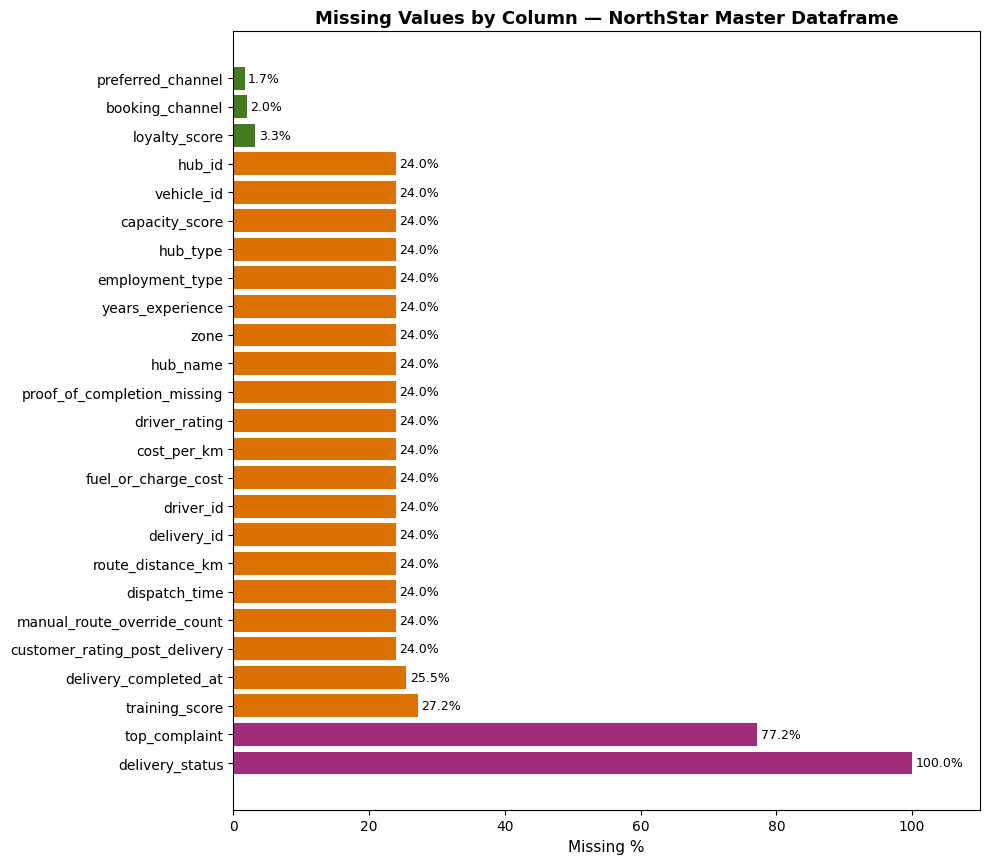


Columns with >30% missing (excluded from modelling):
['delivery_status', 'top_complaint']


In [7]:
missing = master.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0].reset_index()
missing.columns = ["column", "missing_pct"]
missing["missing_pct_label"] = (missing["missing_pct"] * 100).round(1).astype(str) + "%"

fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.35)))
bars = ax.barh(missing["column"], missing["missing_pct"] * 100,
               color=["#a12c7b" if x > 30 else "#da7101" if x > 10 else "#437a22"
                      for x in missing["missing_pct"] * 100])
for bar, label in zip(bars, missing["missing_pct_label"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            label, va="center", fontsize=9)
ax.set_xlabel("Missing %", fontsize=11)
ax.set_title("Missing Values by Column — NorthStar Master Dataframe",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

print("\nColumns with >30% missing (excluded from modelling):")
print(missing[missing["missing_pct"] > 0.3]["column"].tolist())

## NumPy Analysis — Descriptive Statistics


In [8]:
num_features = ["order_value", "route_distance_km", "fuel_or_charge_cost",
                "cost_per_km", "customer_rating_post_delivery",
                "driver_rating", "training_score", "complaint_count",
                "hub_capacity_score", "promised_window_hours"]

num_features = [f for f in num_features if f in master.columns]

results = []
for feat in num_features:
    arr = master[feat].dropna().values
    results.append({
        "Feature"  : feat,
        "Count"    : len(arr),
        "Mean"     : np.round(np.mean(arr), 2),
        "Median"   : np.round(np.median(arr), 2),
        "Std Dev"  : np.round(np.std(arr), 2),
        "Min"      : np.round(np.min(arr), 2),
        "Max"      : np.round(np.max(arr), 2),
        "IQR"      : np.round(np.percentile(arr, 75) - np.percentile(arr, 25), 2),
        "Skewness" : np.round(stats.skew(arr), 3)
    })

stats_df = pd.DataFrame(results)
print(stats_df.to_string(index=False))

                      Feature  Count                   Mean  Median                Std Dev                     Min    Max   IQR  Skewness
                  order_value   1250                  91.05   76.53                  60.89                    2.04 510.06 73.18      1.34
            route_distance_km    950                  13.91   12.84                   7.47                    1.20  41.94  7.70      1.05
          fuel_or_charge_cost    950                  12.84   12.64                   4.33                    2.50  29.43  5.77      0.24
                  cost_per_km    950                   1.26    0.95                   1.24                    0.17  12.35  0.63      4.77
customer_rating_post_delivery    950 -135923377385228272.00    4.00 1111394040657932672.00 -9223372036854775808.00   5.00  1.00     -8.05
                driver_rating    950                   4.16    4.17                   0.41                    3.15   5.00  0.56     -0.18
               training_score    9

## Pandas Analysis — Group-level Aggregations

In [9]:
# ── Revenue & complaint rate by service type ──
if "service_type" in master.columns:
    svc = master.groupby("service_type").agg(
        total_orders    =("order_id",                    "count"),
        total_revenue   =("order_value",                 "sum"),
        avg_order_value =("order_value",                 "mean"),
        avg_rating      =("customer_rating_post_delivery","mean"),
        complaint_rate  =("has_complaint",               "mean")
    ).round(2).sort_values("total_revenue", ascending=False).reset_index()
    svc["complaint_rate_%"] = (svc["complaint_rate"] * 100).round(1)
    print("── Revenue & Complaint Rate by Service Type ──")
    print(svc.drop("complaint_rate", axis=1).to_string(index=False))

# ── Delivery performance by zone ──
if "pickup_zone" in master.columns and "delivery_status" in master.columns:
    zone = master.groupby("pickup_zone").agg(
        total=("order_id", "count"),
        failed=("delivery_status", lambda x: (x == "Failed").sum()),
        avg_cost_per_km=("cost_per_km", "mean")
    ).reset_index()
    zone["failure_rate_%"] = (zone["failed"] / zone["total"] * 100).round(1)
    zone = zone.sort_values("failure_rate_%", ascending=False)
    print("\n── Delivery Failure Rate by Pickup Zone ──")
    print(zone.to_string(index=False))

# ── Driver performance by employment type ──
if "employment_type" in master.columns:
    drv = master.groupby("employment_type").agg(
        orders=("order_id", "count"),
        avg_rating=("driver_rating", "mean"),
        avg_training=("training_score", "mean"),
        avg_complaint=("complaint_count", "mean")
    ).round(2).reset_index()
    print("\n── Driver Performance by Employment Type ──")
    print(drv.to_string(index=False))


── Revenue & Complaint Rate by Service Type ──
service_type  total_orders  total_revenue  avg_order_value             avg_rating  complaint_rate_%
   Passenger           341       32761.11            96.07 -176018550321656032.00             23.00
      Parcel           308       26985.62            87.62 -160406470206170016.00             22.00
      Retail           297       26734.06            90.01 -164703072086692416.00             24.00
    Business           165       15220.43            92.25  -73201365371863296.00             21.00
     Medical           139       12111.93            87.14                   3.41             24.00

── Delivery Failure Rate by Pickup Zone ──
pickup_zone  total  failed  avg_cost_per_km  failure_rate_%
    AIRPORT     59       0             0.64            0.00
    Airport     85       0             0.60            0.00
    CENTRAL     79       0             1.21            0.00
    Central     79       0             1.25            0.00
        C

## Pairplot — All Numerical Features

Pair columns   : ['order_value', 'route_distance_km', 'fuel_or_charge_cost', 'cost_per_km', 'customer_rating_post_delivery', 'driver_rating', 'complaint_count']
Hue column     : None
pair_df shape  : (950, 7)
Delivery status values: N/A


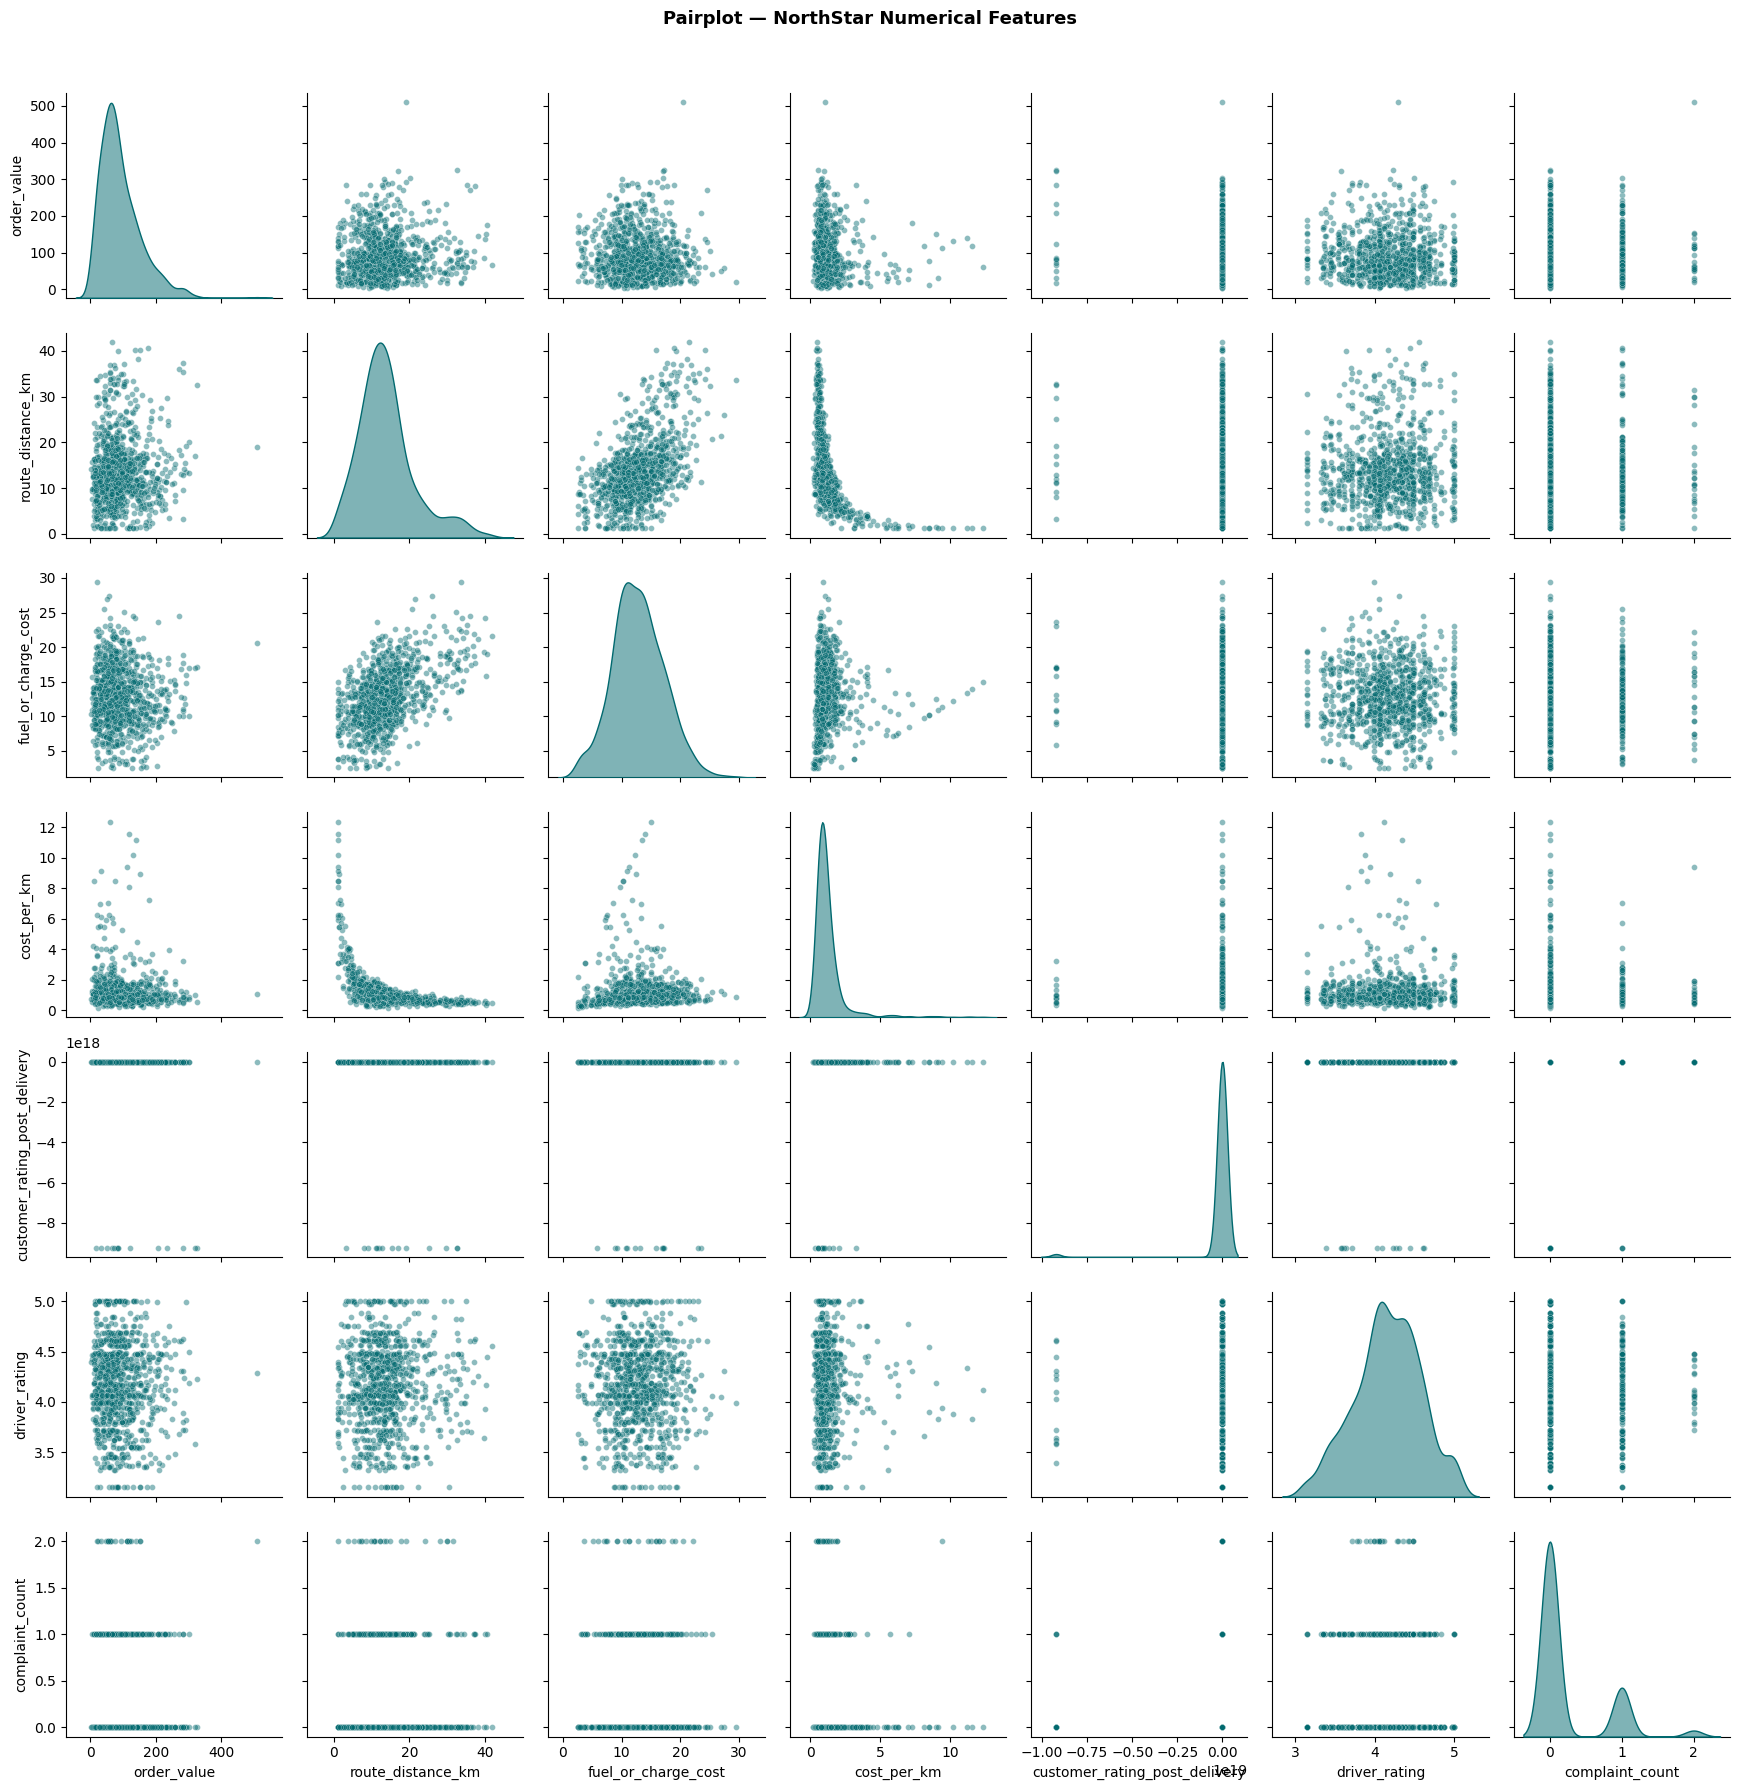

✅ Pairplot rendered.


In [13]:
import warnings
warnings.filterwarnings("ignore")

# Build pair_df fresh from master directly — don't rely on hue_col check
pair_cols = [c for c in ["order_value", "route_distance_km", "fuel_or_charge_cost",
                          "cost_per_km", "customer_rating_post_delivery",
                          "driver_rating", "complaint_count"]
             if c in master.columns]

# Check delivery_status exists and has real values
hue_col = None
if "delivery_status" in master.columns:
    if master["delivery_status"].notna().sum() > 10:
        hue_col = "delivery_status"

print(f"Pair columns   : {pair_cols}")
print(f"Hue column     : {hue_col}")

# Build pair_df — drop NaN only on numeric cols, keep hue separately
pair_df = master[pair_cols].copy()
pair_df = pair_df.dropna()

# Add hue back after dropna (align by index)
if hue_col:
    pair_df[hue_col] = master.loc[pair_df.index, hue_col]
    pair_df = pair_df.dropna(subset=[hue_col])

print(f"pair_df shape  : {pair_df.shape}")
print(f"Delivery status values: {pair_df[hue_col].value_counts().to_dict() if hue_col else 'N/A'}")

# Plot
palette = {"OnTime": "#437a22", "Late": "#da7101", "Failed": "#a12c7b"}

if hue_col and pair_df[hue_col].nunique() > 0:
    g = sns.pairplot(
        pair_df,
        hue      = hue_col,
        palette  = palette,
        diag_kind= "kde",
        plot_kws = {"alpha": 0.45, "s": 18},
        diag_kws = {"fill": True, "alpha": 0.5}
    )
else:
    # No hue available — plot without colour grouping
    g = sns.pairplot(
        pair_df[pair_cols],
        diag_kind= "kde",
        plot_kws = {"alpha": 0.45, "s": 18, "color": "#01696f"},
        diag_kws = {"fill": True, "alpha": 0.5, "color": "#01696f"}
    )

g.figure.suptitle(
    "Pairplot — NorthStar Numerical Features",
    y=1.02, fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()
print("✅ Pairplot rendered.")

## Correlation Heatmap

Rows used for correlation: 950
Any NaNs: 0

Correlation matrix preview:
                               order_value  route_distance_km  \
order_value                           1.00               0.06   
route_distance_km                     0.06               1.00   
fuel_or_charge_cost                  -0.03               0.52   
cost_per_km                          -0.04              -0.51   
customer_rating_post_delivery        -0.10              -0.05   
driver_rating                        -0.02               0.03   
complaint_count                       0.02              -0.01   

                               fuel_or_charge_cost  cost_per_km  \
order_value                                  -0.03        -0.04   
route_distance_km                             0.52        -0.51   
fuel_or_charge_cost                           1.00         0.01   
cost_per_km                                   0.01         1.00   
customer_rating_post_delivery                -0.04         0.02   
drive

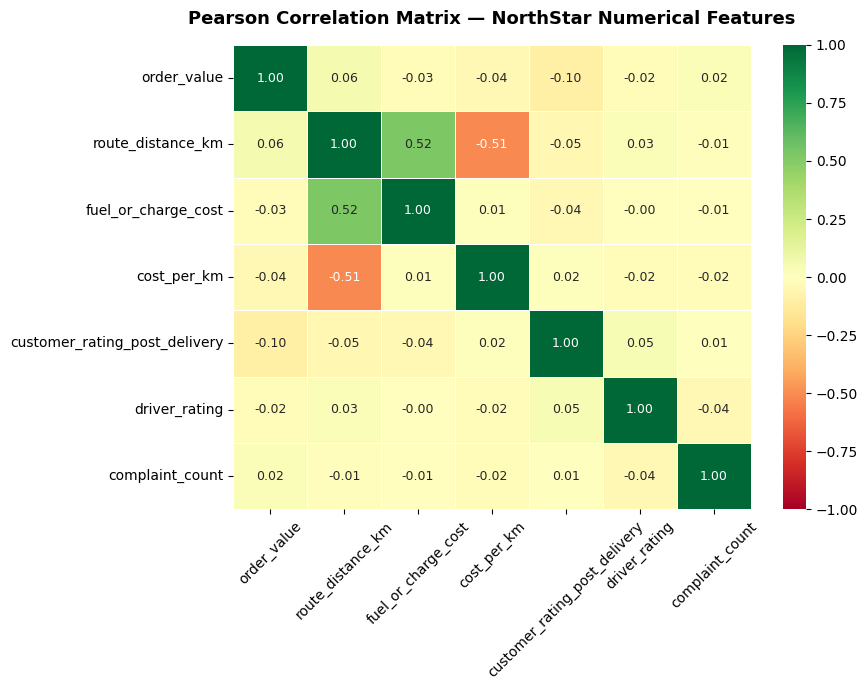


Top 5 Strongest Correlations:
                    Feature A         Feature B     r
          fuel_or_charge_cost route_distance_km  0.52
                  cost_per_km route_distance_km -0.51
customer_rating_post_delivery       order_value -0.10
                  order_value route_distance_km  0.06
customer_rating_post_delivery route_distance_km -0.05


In [14]:
# Use pair_df numeric cols only — already cleaned above
corr_df = pair_df[pair_cols].copy()

print(f"Rows used for correlation: {len(corr_df)}")
print(f"Any NaNs: {corr_df.isnull().sum().sum()}")

corr_matrix = corr_df.corr()
print("\nCorrelation matrix preview:")
print(corr_matrix.round(2))

# Plot heatmap — no mask so all cells show (easier to read for markers)
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = ".2f",
    cmap       = "RdYlGn",
    center     = 0,
    vmin       = -1, vmax = 1,
    linewidths = 0.5,
    ax         = ax,
    annot_kws  = {"size": 9}
)
ax.set_title("Pearson Correlation Matrix — NorthStar Numerical Features",
             fontsize=13, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

# Top 5 strongest correlations
corr_unstacked = corr_matrix.unstack().reset_index()
corr_unstacked.columns = ["Feature A", "Feature B", "r"]
corr_unstacked = corr_unstacked[corr_unstacked["Feature A"] < corr_unstacked["Feature B"]]
corr_unstacked["abs_r"] = corr_unstacked["r"].abs()
top5 = corr_unstacked.nlargest(5, "abs_r")[["Feature A", "Feature B", "r"]]
print("\nTop 5 Strongest Correlations:")
print(top5.to_string(index=False))

### The consolidated master dataframe is exported as a CSV and saved to Google Drive for use in MongoDB + Python analytics.

In [12]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

export_path = "/content/drive/MyDrive/NorthStar_master.csv"
master.to_csv(export_path, index=False)

print(f"✅ Master dataframe exported.")
print(f"   Path : {export_path}")
print(f"   Shape: {master.shape}")
print(f"   Columns: {list(master.columns)}")

Mounted at /content/drive
✅ Master dataframe exported.
   Path : /content/drive/MyDrive/NorthStar_master.csv
   Shape: (1250, 46)
   Columns: ['order_id', 'customer_id', 'service_type', 'order_created_at', 'promised_window_hours', 'pickup_zone', 'dropoff_zone', 'priority_level', 'order_value', 'booking_channel', 'special_handling_flag', 'order_date', 'order_month', 'order_dow', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status', 'delivery_id', 'driver_id', 'vehicle_id', 'hub_id', 'dispatch_time', 'delivery_completed_at', 'delivery_status', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost', 'cost_per_km', 'complaint_count', 'has_complaint', 'top_complaint', 'driver_rating', 'training_score', 'years_experience', 'employment_type', 'hub_name', 'zone', 'hub_type', 'capacity_score']
